In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
#chargement
algeria_shape = gpd.read_file("dza_gc_adg.shp")
tunisia_shape = gpd.read_file("tun_gc_adg.shp")

print("\n Exploration et Nettoyage Algerie ")
print(algeria_shape.info())
print("\nAperçu :")
print(algeria_shape.head())
print("\nValeurs manquantes :")
print(algeria_shape.isna().sum())

tunisia_shape = tunisia_shape.rename(columns={
    'AREA_M2': 'AREA',
    'LCCCode': 'LCCCODE'
})

print("\nExploration et Nettoyage  Tunisie ")
print(tunisia_shape.info())
print("\nAperçu :")
print(tunisia_shape.head())
print("\nValeurs manquantes :")
print(tunisia_shape.isna().sum())

#ajouter une colonne 'country'
algeria_shape["country"] = "Algeria"
tunisia_shape["country"] = "Tunisia"




 Exploration et Nettoyage Algerie 
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 386454 entries, 0 to 386453
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   ID        386454 non-null  int32   
 1   GRIDCODE  386454 non-null  int32   
 2   AREA      386454 non-null  float64 
 3   LCCCODE   386454 non-null  object  
 4   geometry  386454 non-null  geometry
dtypes: float64(1), geometry(1), int32(2), object(1)
memory usage: 11.8+ MB
None

Aperçu :
   ID  GRIDCODE          AREA       LCCCODE  \
0   4       210  6.228187e+06  7001 // 8001   
1   2       210  6.242408e+06  7001 // 8001   
2   1       210  1.482995e+06  7001 // 8001   
3   8        50  4.590841e+08  21497-121340   
4  13       210  6.371533e+06  7001 // 8001   

                                            geometry  
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...  
1  POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...  
2  POLYGON ((7.37137

In [3]:
merged_shape = pd.concat([algeria_shape, tunisia_shape], ignore_index=True)

Colonnes disponibles : ['ID', 'GRIDCODE', 'AREA', 'LCCCODE', 'country']


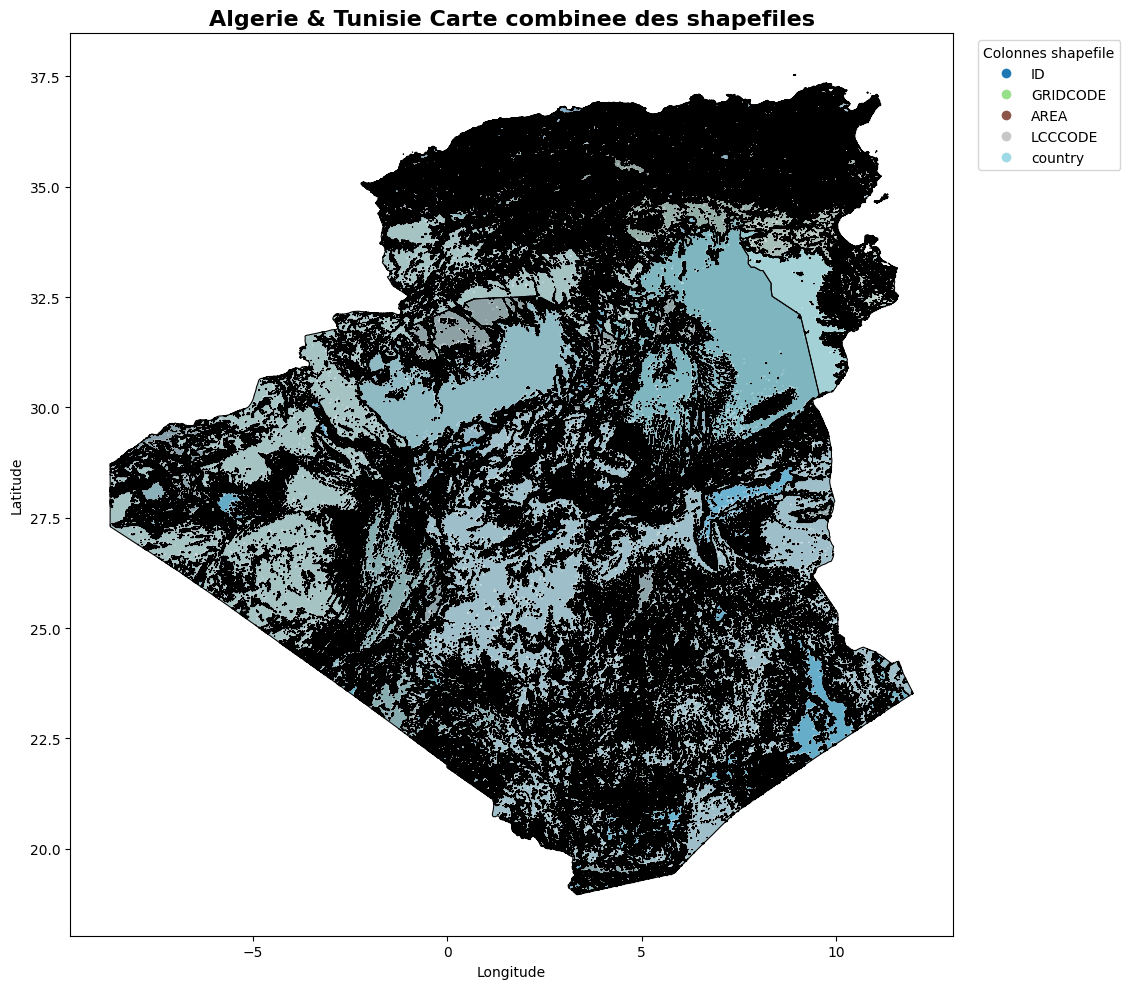

In [ ]:

#colonnes disponibles
cols_to_plot = [c for c in merged_shape.columns if c != "geometry"]
print(f"Colonnes disponibles : {cols_to_plot}")

fig, ax = plt.subplots(figsize=(12, 10))

# des couleurs claire pour eviter le noir
colors = plt.colormaps.get_cmap("tab20").resampled(len(cols_to_plot))

#tracer chaque couche de colonnes
for i, col in enumerate(cols_to_plot):
    try:
        if merged_shape[col].notna().any():
            merged_shape.plot(
                ax=ax,
                column=col,
                cmap="tab20",
                alpha=0.25,  # transparence legère pour voir la superposition
                edgecolor="white",  # contour blanc pour eviter le noir
                legend=False
            )
    except Exception as e:
        print(f"Impossible de tracer la colonne {col}: {e}")

#ajouter les contours


merged_shape.boundary.plot(ax=ax, color="black", linewidth=0.8)

#titrre et labek
ax.set_title("Algerie & Tunisie Carte combinee des shapefiles", fontsize=16, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Legende les colomn et sans coleur
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colors(i / len(cols_to_plot)),
               markersize=8, label=col)
    for i, col in enumerate(cols_to_plot)
]
ax.legend(handles=legend_elements, title="Colonnes shapefile", loc='upper left', bbox_to_anchor=(1.02, 1))
#sauvgarde
plt.tight_layout()
plt.savefig("algerie_tunisie_carte.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
#nettoyage merged

# supprimer les doublons
before_rows = len(merged_shape)
merged_shape = merged_shape.drop_duplicates()
after_rows = len(merged_shape)
print(f"Doublons supprimes (merged) : {before_rows - after_rows}")

print(f"Colonnes après suppression: {list(merged_shape.columns)}")
print(f"Dimensions du dataset: {merged_shape.shape}")


# nettoyer les geometries invalides
invalid_geo = merged_shape[~merged_shape.is_valid]
print(f"Geometries invalides (merged) : {len(invalid_geo)}")
merged_shape = merged_shape[merged_shape.is_valid]

Doublons supprimes (merged) : 0
Colonnes après suppression: ['ID', 'GRIDCODE', 'AREA', 'LCCCODE', 'geometry', 'country']
Dimensions du dataset: (438513, 6)
Geometries invalides (merged) : 8932


avant    ID  GRIDCODE        AREA       LCCCODE  \
0   4       210  6228187.24  7001 // 8001   
1   2       210  6242408.17  7001 // 8001   
2   1       210  1482994.90  7001 // 8001   
4  13       210  6371532.54  7001 // 8001   
6  14       130  1903569.66         21450   

                                            geometry  country  
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...  Algeria  
1  POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...  Algeria  
2  POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...  Algeria  
4  POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...  Algeria  
6  POLYGON ((6.44583 37.07917, 6.44583 37.08194, ...  Algeria  


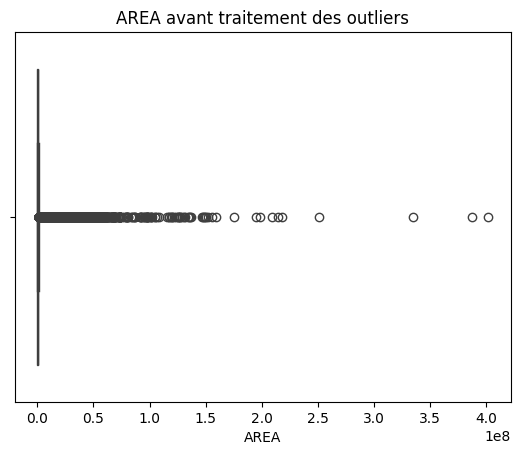

apres    GRIDCODE      AREA  LCCCODE  \
0        21  0.015257       19   
1        21  0.015292       19   
2        21  0.003443       19   
4        21  0.015614       19   
6        10  0.004490        9   

                                            geometry  country  
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...        0  
1  POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...        0  
2  POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...        0  
4  POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...        0  
6  POLYGON ((6.44583 37.07917, 6.44583 37.08194, ...        0  


In [5]:
print("avant",merged_shape.head())

# 🔹 Détection des outliers sur AREA
sns.boxplot(x=merged_shape['AREA'])
plt.title("AREA avant traitement des outliers")
plt.show()

merged_shape = merged_shape.drop(columns=['ID'])
# 🔹 Nettoyage de la colonne LCCCODE
merged_shape["LCCCODE"] = merged_shape["LCCCODE"].astype(str).str.replace("//", "-")
merged_shape["LCCCODE"] = merged_shape["LCCCODE"].str.split("-").str[0]

# 🔹 Encodage
encoder = LabelEncoder()
merged_shape["GRIDCODE"] = encoder.fit_transform(merged_shape["GRIDCODE"])
merged_shape["LCCCODE"] = encoder.fit_transform(merged_shape["LCCCODE"])
merged_shape["country"] = merged_shape["country"].astype("category").cat.codes

# 🔹 Normalisation des valeurs d’AREA
scaler = MinMaxScaler()
merged_shape['AREA'] = scaler.fit_transform(merged_shape[['AREA']])

print("apres",merged_shape.head())

In [6]:
if not isinstance(merged_shape, gpd.GeoDataFrame):
    merged_shape = gpd.GeoDataFrame(merged_shape, geometry='geometry')

# Définir ou convertir le CRS vers EPSG:4326
if merged_shape.crs is None:
    merged_shape = merged_shape.set_crs(epsg=4326)
else:
    merged_shape = merged_shape.to_crs(epsg=4326)

# Sauvegarder dans un fichier shapefile
output_path = "merged/merged_shape.shp"
merged_shape.to_file(output_path, driver='ESRI Shapefile', encoding='utf-8')

print(f"✅ Fichier sauvegardé avec succès : {output_path}")
print("📍 CRS du fichier :", merged_shape.crs)

✅ Fichier sauvegardé avec succès : merged/merged_shape.shp
📍 CRS du fichier : EPSG:4326


In [7]:
merg_shape = gpd.read_file("merged/merged_shape.shp")
print(merg_shape.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 429581 entries, 0 to 429580
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   GRIDCODE  429581 non-null  int64   
 1   AREA      429581 non-null  float64 
 2   LCCCODE   429581 non-null  int64   
 3   country   429581 non-null  int32   
 4   geometry  429581 non-null  geometry
dtypes: float64(1), geometry(1), int32(1), int64(2)
memory usage: 14.7 MB
None
